- In this dataset cols have nomenclature 
- '_cat' for categorical cols.
- '_bin' for binary cols.
- everything else is numeric cols.
 

## Train Dataset 

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../Raw-Dataset/train.csv', index_col="id")
df.head()

,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
id,,,,,,,,,,,,,,,,,,,,,
7,0,2,2,5,1,0,0,1,0,0,...,9,1,5,8,0,1,1,0,0,1
9,0,1,1,7,0,0,0,0,1,0,...,3,1,1,9,0,1,1,0,1,0
13,0,5,4,9,1,0,0,0,1,0,...,4,2,7,7,0,1,1,0,1,0
16,0,0,1,2,0,0,1,0,0,0,...,2,2,4,9,0,0,0,0,0,0
17,0,0,2,0,1,0,1,0,0,0,...,3,1,1,3,0,0,0,1,1,0


In [2]:
columns = df.columns
cat_cols = [col for col in columns if col.endswith('_cat')]
bin_cols = [col for col in columns if col.endswith('_bin')]
numeric_cols = [col for col in columns if col not in cat_cols + bin_cols + ['id', 'target']]
print(cat_cols)
print(bin_cols)
print(numeric_cols)

['ps_ind_02_cat', 'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat', 'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat', 'ps_car_10_cat', 'ps_car_11_cat']
['ps_ind_06_bin', 'ps_ind_07_bin', 'ps_ind_08_bin', 'ps_ind_09_bin', 'ps_ind_10_bin', 'ps_ind_11_bin', 'ps_ind_12_bin', 'ps_ind_13_bin', 'ps_ind_16_bin', 'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_calc_15_bin', 'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin', 'ps_calc_19_bin', 'ps_calc_20_bin']
['ps_ind_01', 'ps_ind_03', 'ps_ind_14', 'ps_ind_15', 'ps_reg_01', 'ps_reg_02', 'ps_reg_03', 'ps_car_11', 'ps_car_12', 'ps_car_13', 'ps_car_14', 'ps_car_15', 'ps_calc_01', 'ps_calc_02', 'ps_calc_03', 'ps_calc_04', 'ps_calc_05', 'ps_calc_06', 'ps_calc_07', 'ps_calc_08', 'ps_calc_09', 'ps_calc_10', 'ps_calc_11', 'ps_calc_12', 'ps_calc_13', 'ps_calc_14']


In [3]:
print(len(cat_cols))
print(len(bin_cols))
print(len(numeric_cols))

14
17
26


### Missing Values Analysis
- '-1' is for missing values as given in question for all features.

In [4]:
df.replace(-1, np.nan, inplace=True)

,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
id,,,,,,,,,,,,,,,,,,,,,
7,0,2,2.0,5,1.0,0.0,0,1,0,0,...,9,1,5,8,0,1,1,0,0,1
9,0,1,1.0,7,0.0,0.0,0,0,1,0,...,3,1,1,9,0,1,1,0,1,0
13,0,5,4.0,9,1.0,0.0,0,0,1,0,...,4,2,7,7,0,1,1,0,1,0
16,0,0,1.0,2,0.0,0.0,1,0,0,0,...,2,2,4,9,0,0,0,0,0,0
17,0,0,2.0,0,1.0,0.0,1,0,0,0,...,3,1,1,3,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1488013,0,3,1.0,10,0.0,0.0,0,0,0,1,...,4,1,9,6,0,1,1,0,1,1
1488016,0,5,1.0,3,0.0,0.0,0,0,0,1,...,4,1,3,8,1,0,1,0,1,1
1488017,0,1,1.0,10,0.0,0.0,1,0,0,0,...,3,2,2,6,0,0,1,0,0,0


In [5]:
missing = df.isnull().sum()
missing_percent = 100 * missing / len(df)

pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
}).sort_values(by='Missing %', ascending=False)

,Missing Count,Missing %
ps_car_03_cat,411231,69.089837
ps_car_05_cat,266551,44.782531
ps_reg_03,107772,18.106490
ps_car_14,42620,7.160474
ps_car_07_cat,11489,1.930237
ps_ind_05_cat,5809,0.975955
ps_car_09_cat,569,0.095596
ps_ind_02_cat,216,0.036290
ps_car_01_cat,107,0.017977
ps_ind_04_cat,83,0.013945


- Check if missing predicts target

In [6]:
# since missing is not informative
# Remove 'ps_car_03_cat'
df['ps_car_03_cat_missing'] = df['ps_car_03_cat'].isnull().astype(int)

df.groupby('ps_car_03_cat_missing')['target'].mean()

ps_car_03_cat_missing
0    0.044809
1    0.032707
Name: target, dtype: float64

In [7]:
# since missing is not informative
# Remove 'ps_car_05_cat'
df['ps_car_05_cat_missing'] = df['ps_car_05_cat'].isnull().astype(int)

df.groupby('ps_car_05_cat_missing')['target'].mean()

ps_car_05_cat_missing
0    0.040291
1    0.031709
Name: target, dtype: float64

In [8]:
df.drop(['ps_car_03_cat_missing', 'ps_car_05_cat_missing'], axis=1, inplace=True)


In [9]:
df['ps_reg_03_missing'] = df['ps_reg_03'].isnull().astype(int)

df.groupby('ps_reg_03_missing')['target'].mean()

ps_reg_03_missing
0    0.038228
1    0.028393
Name: target, dtype: float64

In [10]:
df.drop(['ps_reg_03_missing'], axis=1, inplace=True)


##### Categorical Cols

- Cols with less then 1% nulls => 'ps_ind_02_cat', 'ps_ind_04_cat', 'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_09_cat'(569), 'ps_ind_05_cat'(5809).
- 'ps_car_07_cat' has (~2%) nulls.
- 'ps_car_05_cat' has 266,551(~45%) nulls.(better to remove them)
- 'ps_car_03_cat' has 411,231(~70%) nulls. (better to remove them)

In [11]:
cat_cols_remove = ['ps_car_05_cat', 'ps_car_03_cat']
cat_cols_new_cat = ['ps_ind_02_cat', 'ps_ind_04_cat', 'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_09_cat', 'ps_ind_05_cat', 'ps_car_07_cat']


##### Numeric Cols

- 'ps_car_11', 'ps_car_12' has 5, 1 nulls.
- 'ps_reg_03' has 107,772(~18%) nulls.
- 'ps_car_14' has 42,620(~7%) nulls.

In [12]:
numeric_cols_impute = ['ps_car_11', 'ps_car_12']
numeric_cols_high_sparse = ['ps_reg_03', 'ps_car_14']

### Distribution

#### Plot numeric cols

- Histplot
- Boxplot
- Skewness
- Kurosis

In [13]:
df[numeric_cols].describe()

,ps_ind_01,ps_ind_03,ps_ind_14,ps_ind_15,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_11,ps_car_12,ps_car_13,...,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14
count,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,487440.000000,595207.000000,595211.000000,595212.000000,...,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000
mean,1.900378,4.423318,0.012451,7.299922,0.610991,0.439184,0.894047,2.346100,0.379947,0.813265,...,1.885886,7.689445,3.005823,9.225904,2.339034,8.433590,5.441382,1.441918,2.872288,7.539026
std,1.983789,2.699902,0.127545,3.546042,0.287643,0.404264,0.345413,0.832495,0.058300,0.224588,...,1.134927,1.334312,1.414564,1.459672,1.246949,2.904597,2.332871,1.202963,1.694887,2.746652
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.061237,0.000000,0.100000,0.250619,...,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,5.000000,0.400000,0.200000,0.633443,2.000000,0.316228,0.670867,...,1.000000,7.000000,2.000000,8.000000,1.000000,6.000000,4.000000,1.000000,2.000000,6.000000
50%,1.000000,4.000000,0.000000,7.000000,0.700000,0.300000,0.801561,3.000000,0.374166,0.765811,...,2.000000,8.000000,3.000000,9.000000,2.000000,8.000000,5.000000,1.000000,3.000000,7.000000
75%,3.000000,6.000000,0.000000,10.000000,0.900000,0.600000,1.083974,3.000000,0.400000,0.906190,...,3.000000,9.000000,4.000000,10.000000,3.000000,10.000000,7.000000,2.000000,4.000000,9.000000
max,7.000000,11.000000,4.000000,13.000000,0.900000,1.800000,4.037945,3.000000,1.264911,3.720626,...,6.000000,10.000000,9.000000,12.000000,7.000000,25.000000,19.000000,10.000000,13.000000,23.000000


##### Histplots

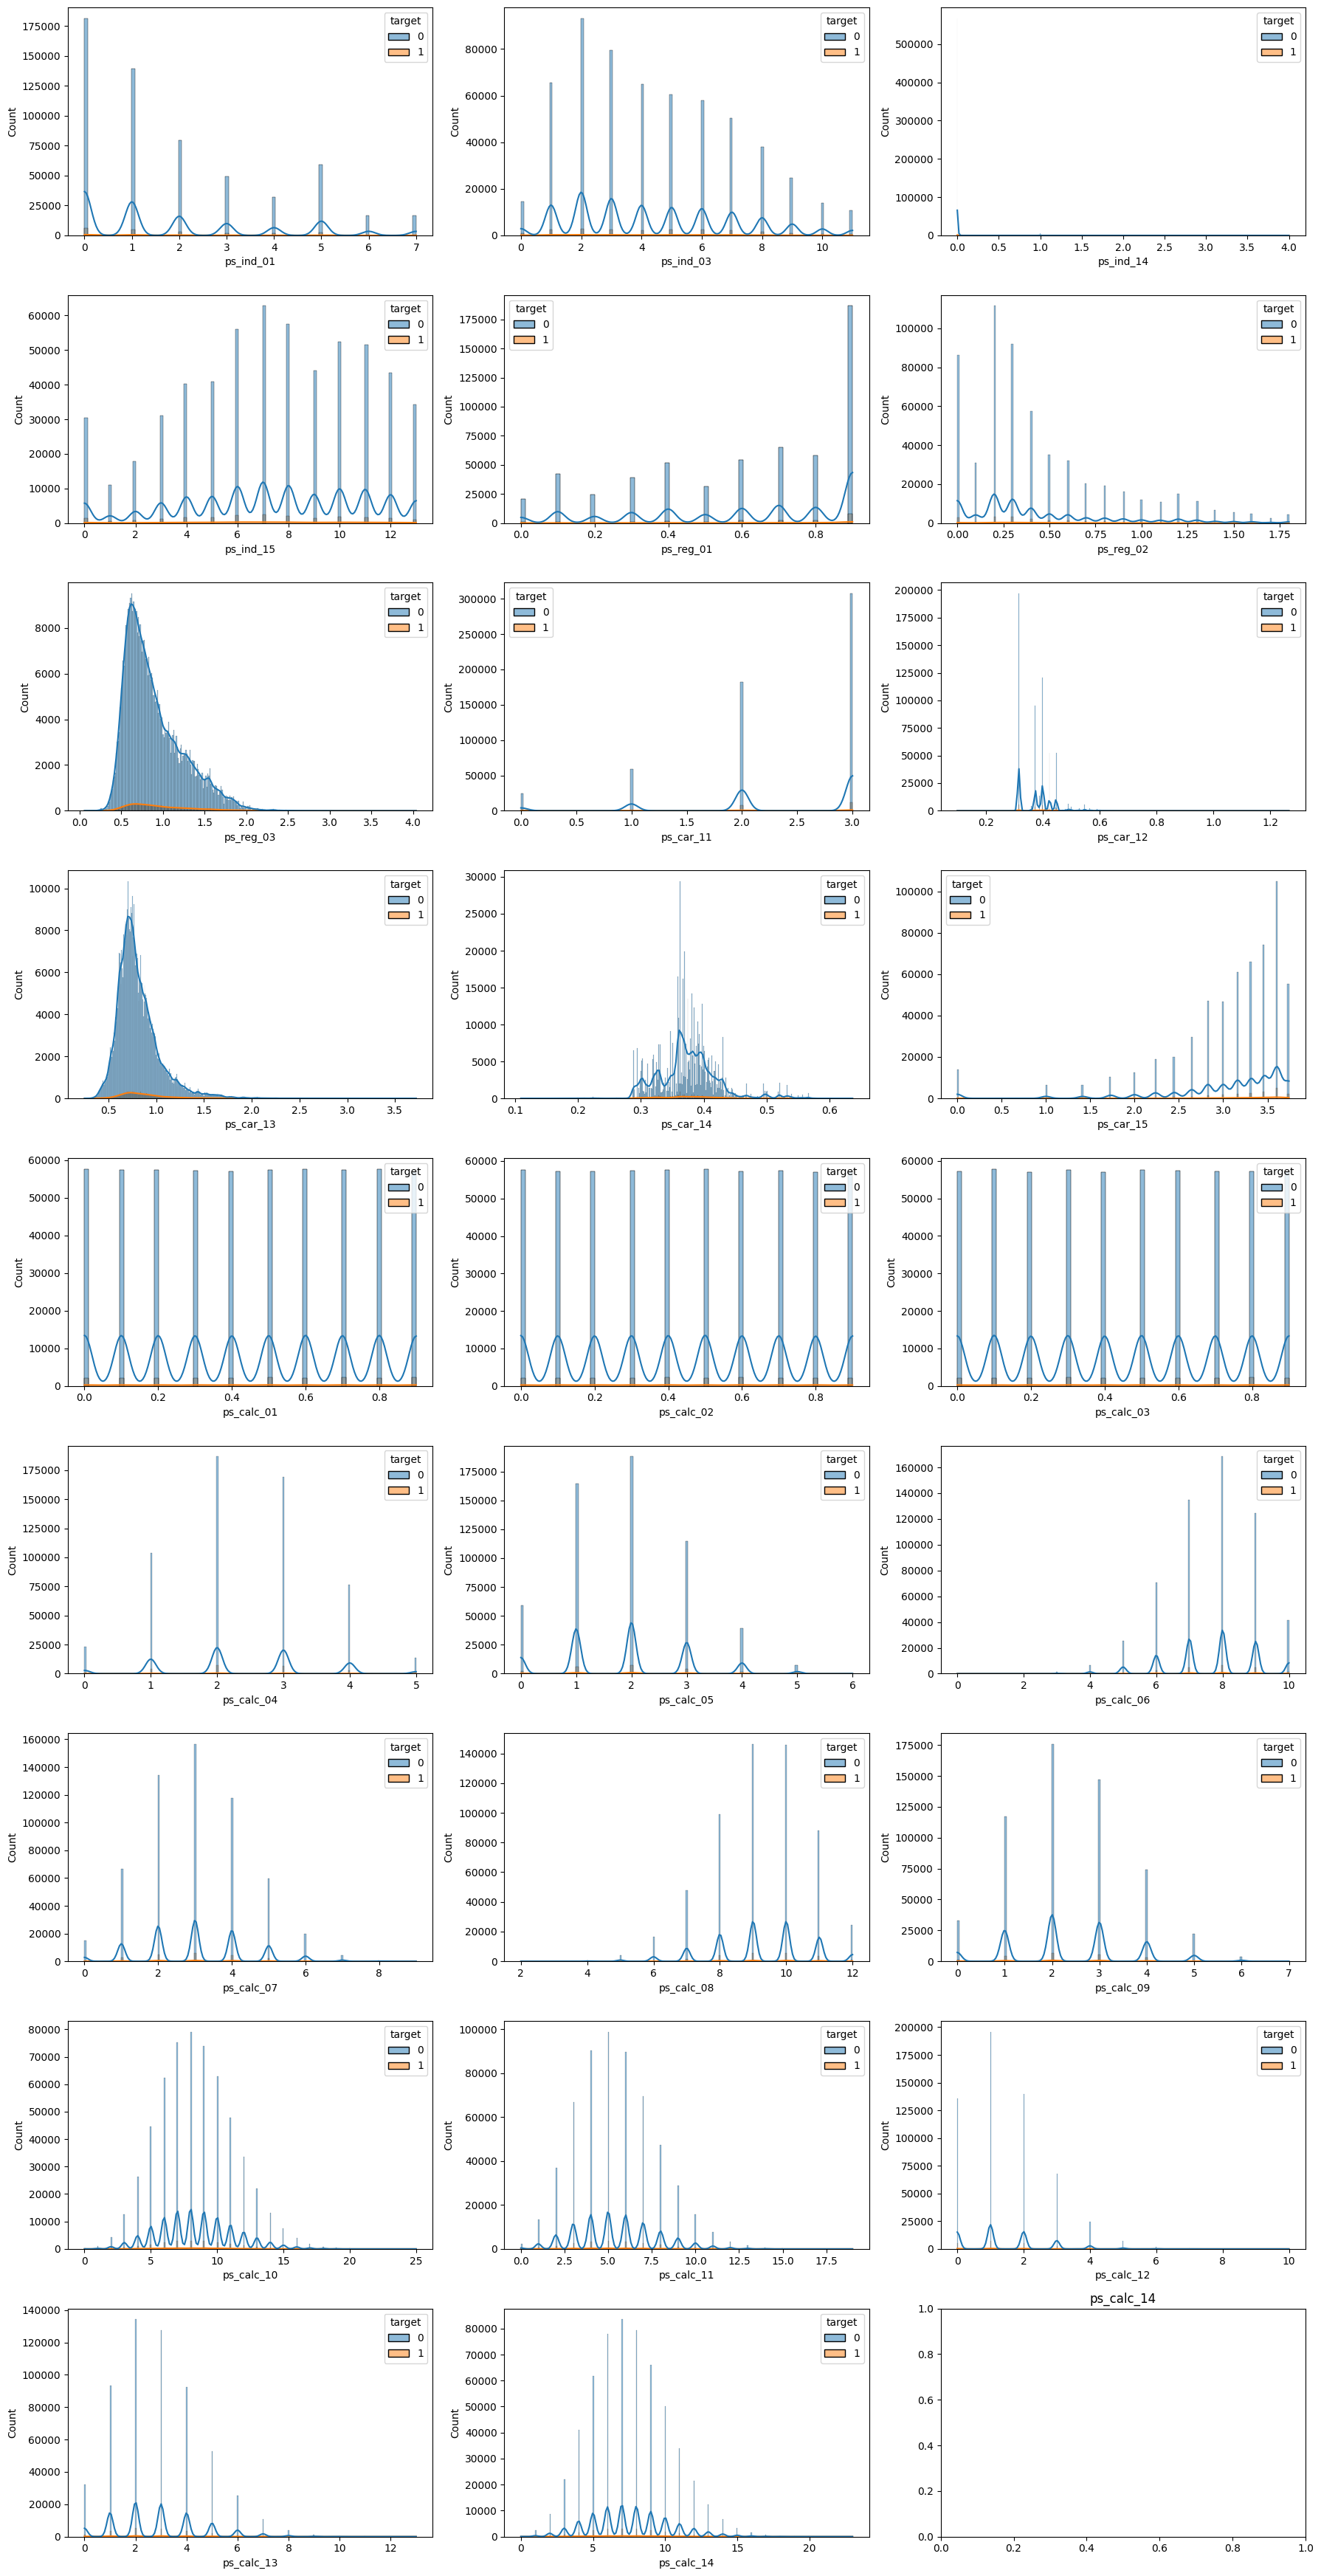

In [14]:
# Histplot
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(nrows=9, ncols=3, figsize=(18, 35))
ax = ax.flatten()

for idx, col in enumerate(numeric_cols):
    sns.histplot(x=col, hue='target', data=df, ax=ax[idx], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

target = 0 dominates
- Severe class imbalance

Critical for modelling
- Accuracy is useless.
- Use AUC, Gini, F1, Precision-Recall
- Use class weights or boosting

In [15]:
ordinal_cat_cols = ['ps_ind_01', 'ps_ind_03', 'ps_ind_14', 'ps_ind_15']

##### Boxplots

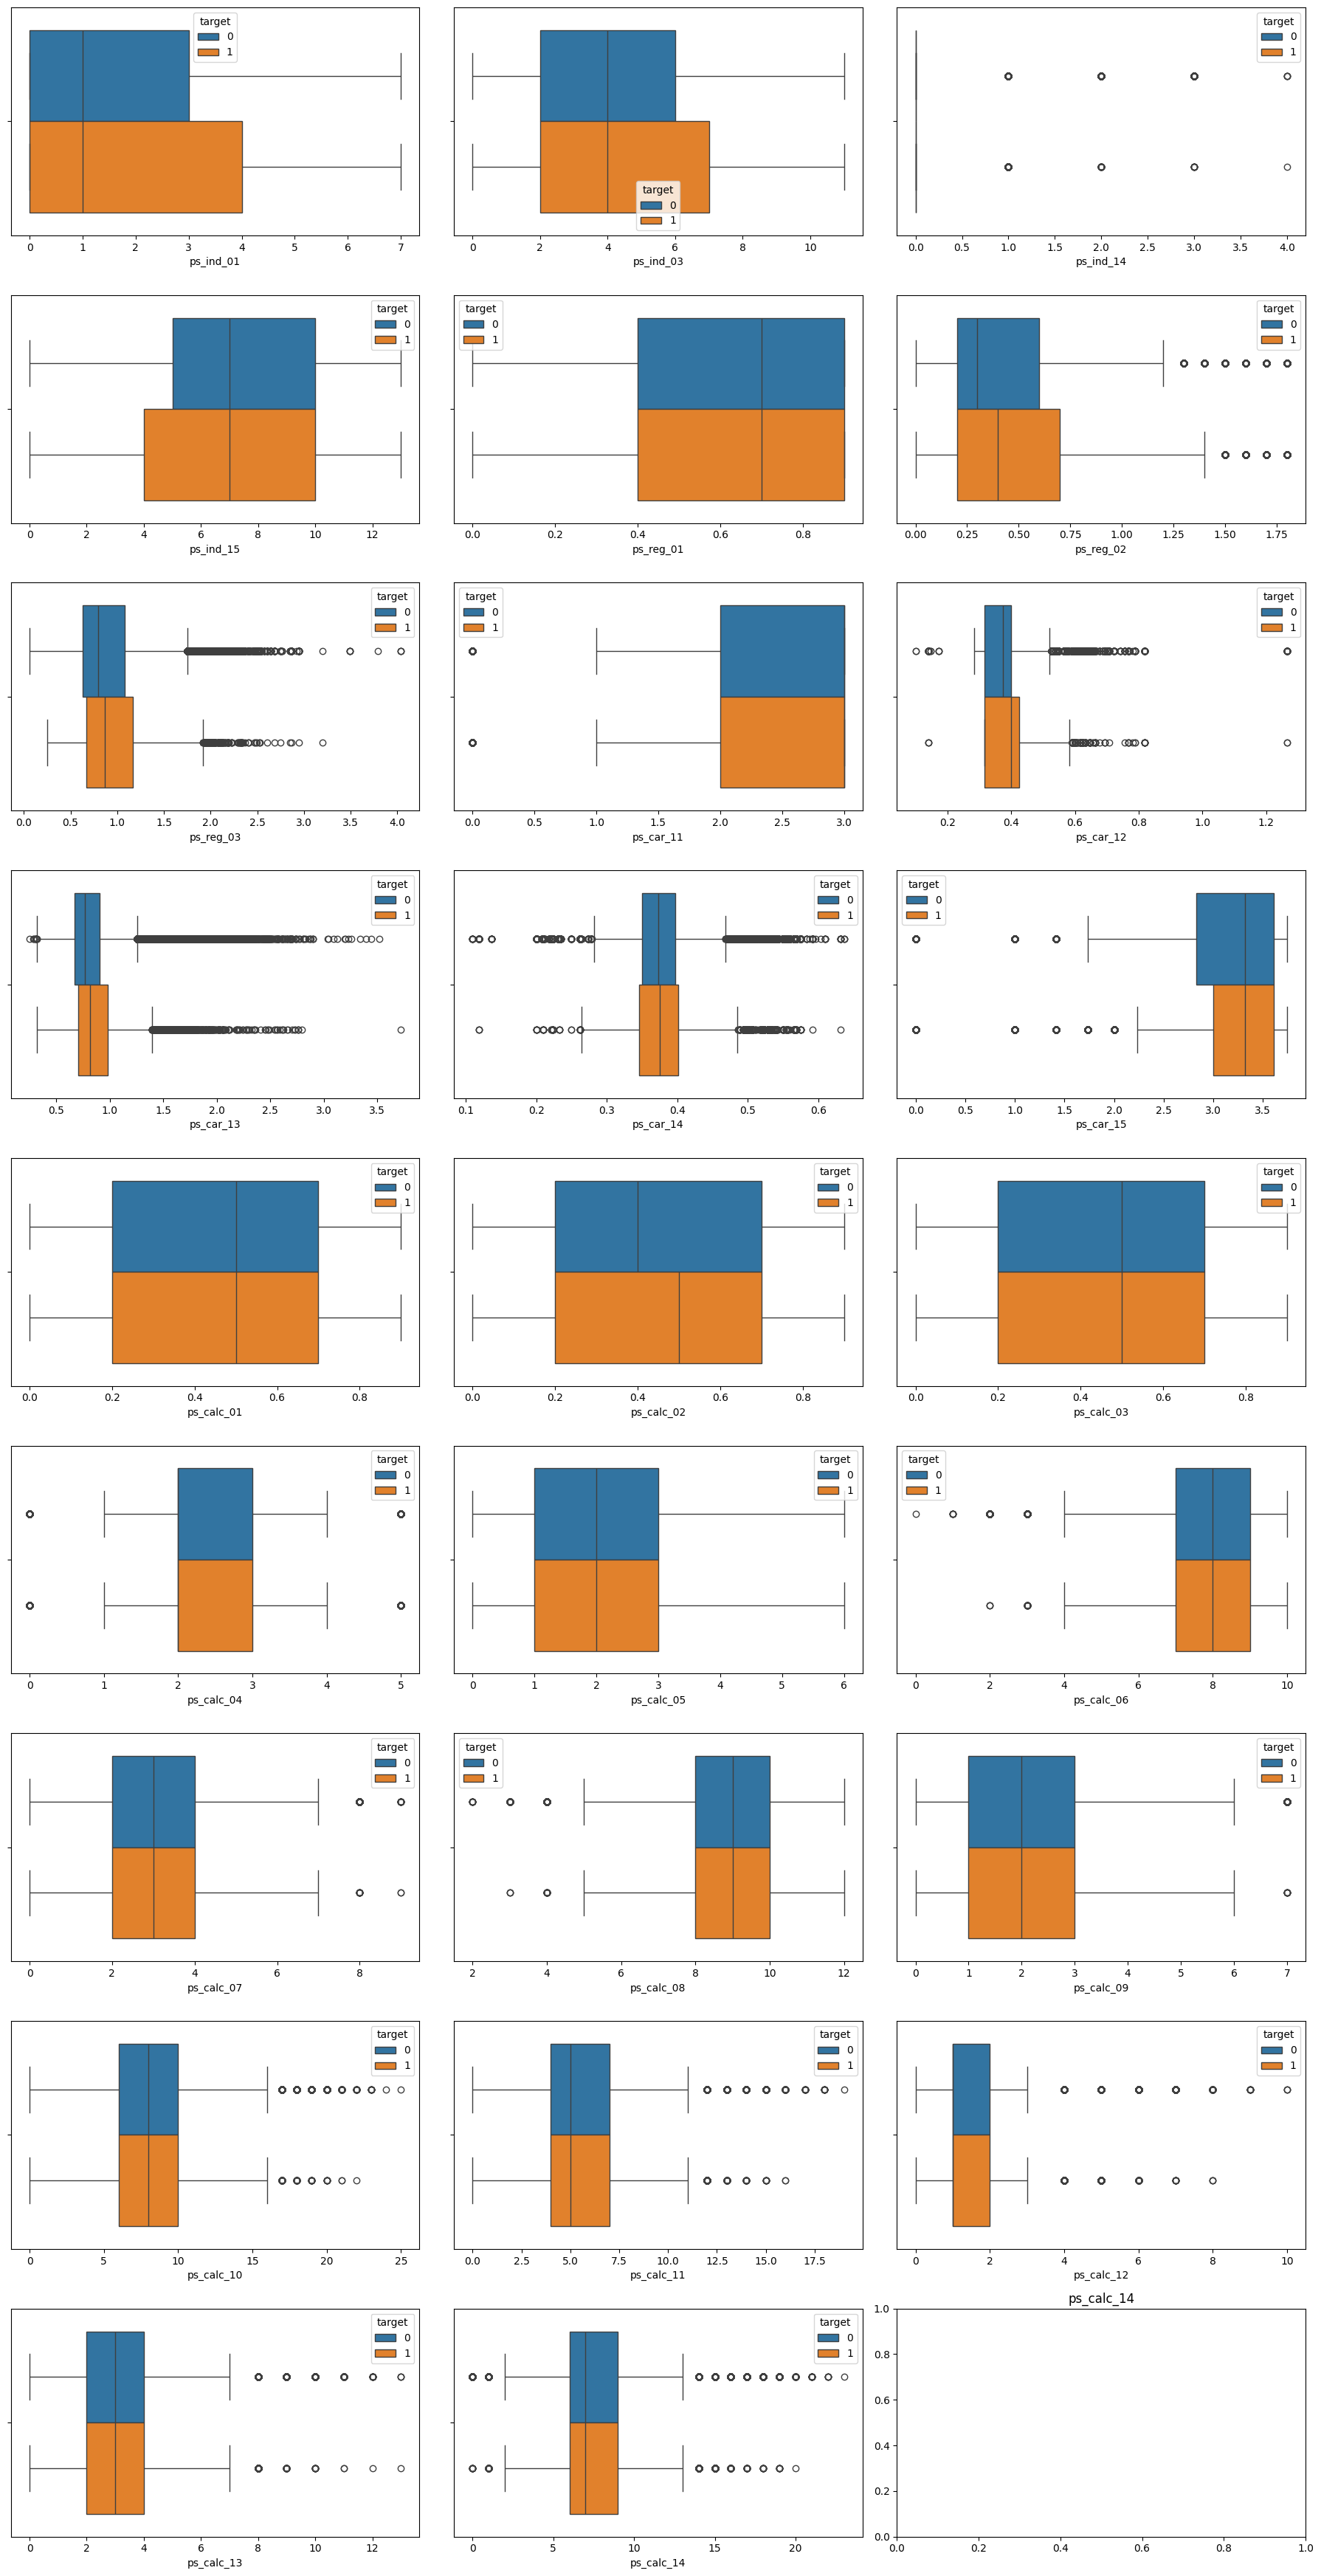

In [16]:
fig, ax = plt.subplots(nrows=9, ncols=3, figsize=(18, 35))
ax = ax.flatten()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=col, hue='target', data=df, ax=ax[idx])
    plt.title(col)
plt.tight_layout()
plt.show()

##### Skewness

In [17]:
skewness = df[numeric_cols].skew()

outliers =  (skewness.abs() > 1).astype(int)

pd.DataFrame({
    'skewness coefficient': skewness,
    'have_outliers': outliers
})

,skewness coefficient,have_outliers
ps_ind_01,0.931680,0
ps_ind_03,0.463530,0
ps_ind_14,12.207636,1
ps_ind_15,-0.285748,0
ps_reg_01,-0.639473,0
ps_reg_02,1.281065,1
ps_reg_03,1.065812,1
ps_car_11,-1.173175,1
ps_car_12,1.090843,1
ps_car_13,1.700536,1


In [24]:
df['ps_ind_01'].skew()

np.float64(0.9316800889420442)

##### Kurtosis

In [18]:
kurt = df[numeric_cols].kurt()

kurt

ps_ind_01      -0.218765
ps_ind_03      -0.650090
ps_ind_14     180.698412
ps_ind_15      -0.735524
ps_reg_01      -0.886951
ps_reg_02       1.123847
ps_reg_03       0.910936
ps_car_11       0.666967
ps_car_12       4.983404
ps_car_13       5.422479
ps_car_14       2.024161
ps_car_15       5.875522
ps_calc_01     -1.224616
ps_calc_02     -1.220190
ps_calc_03     -1.224075
ps_calc_04     -0.404448
ps_calc_05     -0.220849
ps_calc_06     -0.026904
ps_calc_07     -0.175084
ps_calc_08     -0.042165
ps_calc_09     -0.223668
ps_calc_10      0.110992
ps_calc_11      0.179940
ps_calc_12      0.695089
ps_calc_13      0.325962
ps_calc_14      0.135946
dtype: float64

In [32]:
outlier_df = pd.DataFrame({
    'skewness coefficient': skewness,
    'has_outliers': outliers,
    'kurtosis coefficient': kurt  
})
outlier_df

,skewness coefficient,has_outliers,kurtosis coefficient
ps_ind_01,0.931680,0,-0.218765
ps_ind_03,0.463530,0,-0.650090
ps_ind_14,12.207636,1,180.698412
ps_ind_15,-0.285748,0,-0.735524
ps_reg_01,-0.639473,0,-0.886951
ps_reg_02,1.281065,1,1.123847
ps_reg_03,1.065812,1,0.910936
ps_car_11,-1.173175,1,0.666967
ps_car_12,1.090843,1,4.983404
ps_car_13,1.700536,1,5.422479


In [35]:
outlier_method = [
    'z-score' if (row[1] is not None and np.abs(row[2]) < 0.25) else 'iqr' 
    for row in np.array(outlier_df)
]
outlier_df['outlier_method'] = outlier_method
outlier_df

,skewness coefficient,has_outliers,kurtosis coefficient,outlier_method
ps_ind_01,0.931680,0,-0.218765,z-score
ps_ind_03,0.463530,0,-0.650090,iqr
ps_ind_14,12.207636,1,180.698412,iqr
ps_ind_15,-0.285748,0,-0.735524,iqr
ps_reg_01,-0.639473,0,-0.886951,iqr
ps_reg_02,1.281065,1,1.123847,iqr
ps_reg_03,1.065812,1,0.910936,iqr
ps_car_11,-1.173175,1,0.666967,iqr
ps_car_12,1.090843,1,4.983404,iqr
ps_car_13,1.700536,1,5.422479,iqr


- If a numeric cols is:
    - nearly symmetric, and 
    - kurtosis(measure of tails) nearly 0,
- then use z-score.
- else use IQR.

#### Categorical Columns

Checks:
- High cardinality?
- Dominant category?
- Rare Categories?

In [19]:
for col in cat_cols + ordinal_cat_cols:
    print(f"value counts for {col}")
    print(df[col].value_counts(normalize=True))


value counts for ps_ind_02_cat
ps_ind_02_cat
1.0    0.725818
2.0    0.207687
3.0    0.047372
4.0    0.019123
Name: proportion, dtype: float64
value counts for ps_ind_04_cat
ps_ind_04_cat
0.0    0.583008
1.0    0.416992
Name: proportion, dtype: float64
value counts for ps_ind_05_cat
ps_ind_05_cat
0.0    0.895837
6.0    0.035056
4.0    0.031123
1.0    0.014119
3.0    0.013968
2.0    0.007099
5.0    0.002798
Name: proportion, dtype: float64
value counts for ps_car_01_cat
ps_car_01_cat
11.0    0.348801
7.0     0.301202
6.0     0.104844
10.0    0.084165
4.0     0.043982
9.0     0.034150
5.0     0.030485
8.0     0.025362
3.0     0.011188
0.0     0.009921
2.0     0.003603
1.0     0.002297
Name: proportion, dtype: float64
value counts for ps_car_02_cat
ps_car_02_cat
1.0    0.829947
0.0    0.170053
Name: proportion, dtype: float64
value counts for ps_car_03_cat
ps_car_03_cat
1.0    0.601741
0.0    0.398259
Name: proportion, dtype: float64
value counts for ps_car_04_cat
ps_car_04_cat
0    0.8342

In [20]:
# p(target=1/category)

for col in cat_cols + ordinal_cat_cols:
    print(f"target for each category of column {col}")
    print(df.groupby(col)['target'].mean())

target for each category of column ps_ind_02_cat
ps_ind_02_cat
1.0    0.035725
2.0    0.038139
3.0    0.037217
4.0    0.040780
Name: target, dtype: float64
target for each category of column ps_ind_04_cat
ps_ind_04_cat
0.0    0.034790
1.0    0.038644
Name: target, dtype: float64
target for each category of column ps_ind_05_cat
ps_ind_05_cat
0.0    0.033865
1.0    0.047825
2.0    0.075526
3.0    0.042998
4.0    0.052061
5.0    0.048514
6.0    0.059336
Name: target, dtype: float64
target for each category of column ps_car_01_cat
ps_car_01_cat
0.0     0.043869
1.0     0.046818
2.0     0.042910
3.0     0.037549
4.0     0.039161
5.0     0.039246
6.0     0.029763
7.0     0.028770
8.0     0.043398
9.0     0.054421
10.0    0.036976
11.0    0.041581
Name: target, dtype: float64
target for each category of column ps_car_02_cat
ps_car_02_cat
0.0    0.049507
1.0    0.033772
Name: target, dtype: float64
target for each category of column ps_car_03_cat
ps_car_03_cat
0.0    0.039538
1.0    0.048298
N

- `ps_car_11_cat` consider for Target Encoding.

#### Correlation analysis

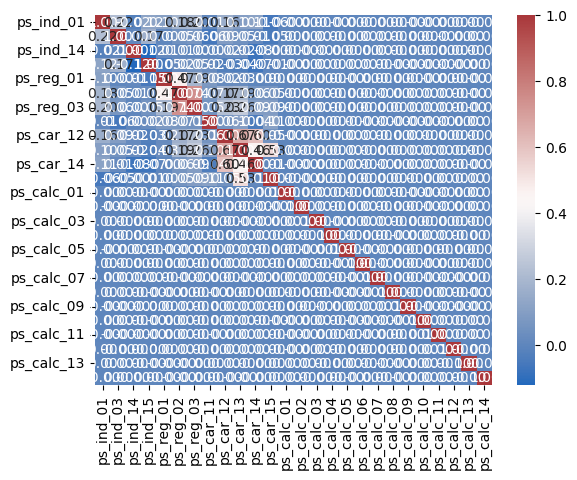

In [21]:
corr = df[numeric_cols].corr()
plt.Figure(figsize=(20, 35))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='vlag')
plt.show()

- All Cols are not related.

#### Class Imbalance


In [22]:
df['target'].value_counts(normalize=True)

target
0    0.963552
1    0.036448
Name: proportion, dtype: float64